# Execution notebook: noiseless subnormalised-state simulation

This notebook is the noiseless counterpart of the noisy execution workflow.

It keeps the paper-style pipeline:
1. generate random paper-style subnormalised one-qubit target states,
2. prepare them with the one-ancilla dilation circuit,
3. do one-qubit tomography on the prepared state,
4. compute fidelity and Frobenius distance,
5. average over all generated states,
6. repeat for different sample sizes.

Two notions of "noiseless" are separated here:
- **shot-limited noiseless**: the circuit is ideal, but ancilla postselection and tomography still use finite sampling;
- **exact noiseless**: the circuit is ideal and exact probabilities are used instead of finite-shot sampling.

That separation is useful because even without physical noise, finite-shot tomography alone can keep the fidelity below 100%.


In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

current_dir = Path.cwd().resolve()
project_root = current_dir
while project_root.name != 'project' and project_root.parent != project_root:
    project_root = project_root.parent
package_parent = project_root.parent if project_root.name == 'project' else current_dir.parent
if str(package_parent) not in sys.path:
    sys.path.insert(0, str(package_parent))

from algo.dilation_algo import hadamard, build_state_preparation_dilation, density_matrix_from_state
from subnorm.state_preparation import paper_style_state_preparation_data

from metric.tomography import (
    basis_probabilities,
    expectation_from_counts,
    linear_inversion_density_matrix,
    project_to_physical_density_matrix,
)
from metric.fidelity_frobenius import evaluate_fidelity_frobenius, summarize_metric_results


## Configuration

Interpretation used in this notebook:
- `sample_size` = ancilla readout shots used to estimate the success probability, and also the number of shots per tomography basis `X`, `Y`, `Z`.
- for one system qubit, the reconstructed subnormalised density is recovered as `2 * p_success * rho_cond`.
- `EXACT_REFERENCE = True` adds one fully exact noiseless row where no sampling is used at all.


In [3]:
NUM_STATES = 98
SAMPLE_SIZES = [64, 256, 1024, 4096, 16384]
STATE_SEED = 1234
BASE_RNG_SEED = 2026
EXACT_REFERENCE = True


## Ideal circuit and tomography helpers

Circuit used for the state-preparation stage:
- start from `|0>_ancilla |0>_system`,
- apply `H` on the system qubit to create the uniform-superposition input,
- apply `H` on the ancilla,
- apply the diagonal dilation unitary `U_Σ`,
- apply the final `H` on the ancilla,
- postselect ancilla outcome `0`.

In this notebook there is **no physical circuit noise and no readout assignment error**.
Only optional finite-shot sampling remains when `sample_size` is an integer.
When `sample_size=None`, all probabilities are used exactly.


In [4]:
H = hadamard()
I2 = np.eye(2, dtype=complex)


def run_ideal_state_preparation_circuit(sample):
    diagonal_dilation = build_state_preparation_dilation(sample.target_subnormalized_state)
    U_sigma = diagonal_dilation.unitary_dilation

    H_system = np.kron(I2, H)
    H_ancilla = np.kron(H, I2)

    psi_in = np.array([1.0, 0.0, 0.0, 0.0], dtype=complex)
    rho = density_matrix_from_state(psi_in)

    rho = H_system @ rho @ H_system.conj().T
    rho = H_ancilla @ rho @ H_ancilla.conj().T
    rho = U_sigma @ rho @ U_sigma.conj().T
    rho = H_ancilla @ rho @ H_ancilla.conj().T

    return np.asarray(rho, dtype=complex)


def extract_success_branch_noiseless(rho_two_qubit, shots=None, rng=None):
    rho = np.asarray(rho_two_qubit, dtype=complex)
    rho_00 = rho[:2, :2]
    rho_11 = rho[2:, 2:]

    p_true_0 = float(np.real(np.trace(rho_00)))
    p_true_1 = float(np.real(np.trace(rho_11)))

    if shots is None:
        p_observed_0 = p_true_0
        counts = None
    else:
        if rng is None:
            rng = np.random.default_rng()
        sampled = rng.multinomial(shots, [p_true_0, p_true_1])
        counts = {'0': int(sampled[0]), '1': int(sampled[1])}
        p_observed_0 = counts['0'] / shots

    rho_conditional = rho_00 / np.trace(rho_00)

    return {
        'p_true_success': p_true_0,
        'p_observed_success': float(p_observed_0),
        'rho_conditional': np.asarray(rho_conditional, dtype=complex),
        'ancilla_counts': counts,
    }


def perform_single_qubit_tomography_noiseless(rho_conditional, shots=None, rng=None):
    measured_expectations = {}
    exact_basis_probabilities = {}
    basis_counts = {}

    for basis in ('X', 'Y', 'Z'):
        probs = basis_probabilities(rho_conditional, basis)
        exact_basis_probabilities[basis] = {'0': float(probs['0']), '1': float(probs['1'])}

        if shots is None:
            measured_expectations[basis] = float(probs['0'] - probs['1'])
            basis_counts[basis] = None
        else:
            if rng is None:
                rng = np.random.default_rng()
            sampled = rng.multinomial(shots, [probs['0'], probs['1']])
            counts = {'0': int(sampled[0]), '1': int(sampled[1])}
            basis_counts[basis] = counts
            measured_expectations[basis] = expectation_from_counts(counts)

    rho_linear = linear_inversion_density_matrix(measured_expectations, trace=1.0)
    rho_physical = project_to_physical_density_matrix(rho_linear)

    return {
        'measured_expectations': measured_expectations,
        'basis_counts': basis_counts,
        'exact_basis_probabilities': exact_basis_probabilities,
        'rho_linear': np.asarray(rho_linear, dtype=complex),
        'rho_physical': np.asarray(rho_physical, dtype=complex),
    }


def run_single_state_pipeline_noiseless(sample, sample_size=None, rng=None):
    rho_two_qubit = run_ideal_state_preparation_circuit(sample)
    postselection = extract_success_branch_noiseless(rho_two_qubit, shots=sample_size, rng=rng)
    tomography = perform_single_qubit_tomography_noiseless(
        postselection['rho_conditional'],
        shots=sample_size,
        rng=rng,
    )
    reconstructed_subnormalized_density = 2.0 * postselection['p_observed_success'] * tomography['rho_physical']
    metric_result = evaluate_fidelity_frobenius(sample.exact_density_matrix, reconstructed_subnormalized_density)
    return {
        'rho_two_qubit_final': rho_two_qubit,
        'postselection': postselection,
        'tomography': tomography,
        'reconstructed_subnormalized_density': reconstructed_subnormalized_density,
        'metric_result': metric_result,
    }


def run_sample_size_sweep_noiseless(samples, sample_sizes, base_seed=0, include_exact_reference=True):
    summary_rows = []
    detailed_results = {}

    if include_exact_reference:
        exact_metric_results = []
        exact_per_state_results = []
        for sample in samples:
            result = run_single_state_pipeline_noiseless(sample, sample_size=None, rng=None)
            exact_per_state_results.append(result)
            exact_metric_results.append(result['metric_result'])
        exact_summary = summarize_metric_results(exact_metric_results, sample_size=-1)
        summary_rows.append(
            {
                'sample_size': 'exact',
                'mean_fidelity': exact_summary.mean_fidelity,
                'std_fidelity': exact_summary.std_fidelity,
                'mean_frobenius_distance': exact_summary.mean_frobenius_distance,
                'std_frobenius_distance': exact_summary.std_frobenius_distance,
            }
        )
        detailed_results['exact'] = exact_per_state_results

    for sample_size in sample_sizes:
        rng = np.random.default_rng(base_seed + int(sample_size))
        metric_results = []
        per_state_results = []

        for sample in samples:
            result = run_single_state_pipeline_noiseless(sample, sample_size=sample_size, rng=rng)
            per_state_results.append(result)
            metric_results.append(result['metric_result'])

        summary = summarize_metric_results(metric_results, sample_size=sample_size)
        summary_rows.append(
            {
                'sample_size': int(sample_size),
                'mean_fidelity': summary.mean_fidelity,
                'std_fidelity': summary.std_fidelity,
                'mean_frobenius_distance': summary.mean_frobenius_distance,
                'std_frobenius_distance': summary.std_frobenius_distance,
            }
        )
        detailed_results[int(sample_size)] = per_state_results

    return pd.DataFrame(summary_rows), detailed_results


## Generate the random target ensemble


In [5]:
samples, ensemble_summary = paper_style_state_preparation_data(
    num_states=NUM_STATES,
    seed=STATE_SEED,
    simulate_dilation=False,
)

print(ensemble_summary)
print(f'Number of generated target states: {len(samples)}')


SubnormalizedStateEnsembleSummary(num_states=98, mean_norm=0.7114463976015258, std_norm=0.16020229808016978, mean_trace=0.5318207529703561, std_trace=0.21434829705755293, min_norm=0.22560082555771788, max_norm=0.9632961741852678)
Number of generated target states: 98


## Single-state sanity check


In [6]:
example_sample = samples[0]
example_rng = np.random.default_rng(BASE_RNG_SEED)
example_result = run_single_state_pipeline_noiseless(
    example_sample,
    sample_size=SAMPLE_SIZES[0],
    rng=example_rng,
)

print('Target subnormalised state vector:')
print(example_sample.target_subnormalized_state)
print()
print('Exact target unnormalised density matrix:')
print(example_sample.exact_density_matrix)
print()
print('Observed ancilla success probability:')
print(example_result['postselection']['p_observed_success'])
print()
print('Tomography reconstructed unnormalised density matrix:')
print(example_result['reconstructed_subnormalized_density'])
print()
print('Fidelity and Frobenius distance:')
print(example_result['metric_result'])


Target subnormalised state vector:
[-0.40787983+0.21966307j  0.01630157+0.74084496j]

Exact target unnormalised density matrix:
[[0.21461782+4.27894175e-18j 0.15608719+3.05756567e-01j]
 [0.15608719-3.05756567e-01j 0.54911699+7.01413762e-19j]]

Observed ancilla success probability:
0.328125

Tomography reconstructed unnormalised density matrix:
[[0.17586969+0.j        0.12180424+0.2639092j]
 [0.12180424-0.2639092j 0.48038031+0.j       ]]

Fidelity and Frobenius distance:
FidelityFrobeniusResult(exact_density_matrix=array([[0.21461782+4.27894175e-18j, 0.15608719+3.05756567e-01j],
       [0.15608719-3.05756567e-01j, 0.54911699+7.01413762e-19j]]), simulated_density_matrix=array([[0.17586969+0.j       , 0.12180424+0.2639092j],
       [0.12180424-0.2639092j, 0.48038031+0.j       ]]), exact_density_matrix_normalized=array([[0.28101091+3.77016665e-18j, 0.20437355+4.00343894e-01j],
       [0.20437355-4.00343894e-01j, 0.71898909-3.77016665e-18j]]), simulated_density_matrix_normalized=array([[0.2

## Sweep over sample size and average over all generated states


In [7]:
summary_df, detailed_results = run_sample_size_sweep_noiseless(
    samples,
    SAMPLE_SIZES,
    base_seed=BASE_RNG_SEED,
    include_exact_reference=EXACT_REFERENCE,
)
summary_df


,sample_size,mean_fidelity,std_fidelity,mean_frobenius_distance,std_frobenius_distance
0,exact,1.000000,7.661902e-09,3.194341e-16,1.986831e-16
1,64,0.981212,2.211933e-02,9.832723e-02,4.893803e-02
2,256,0.991659,1.142538e-02,5.320643e-02,2.961534e-02
3,1024,0.996242,5.272035e-03,2.931548e-02,1.696912e-02
4,4096,0.998080,2.891171e-03,1.347473e-02,8.319782e-03
5,16384,0.998898,1.467442e-03,6.984310e-03,4.249288e-03


## Plot the averaged metrics versus sample size


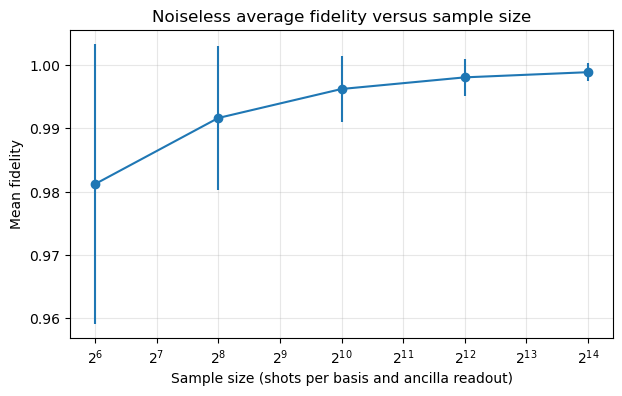

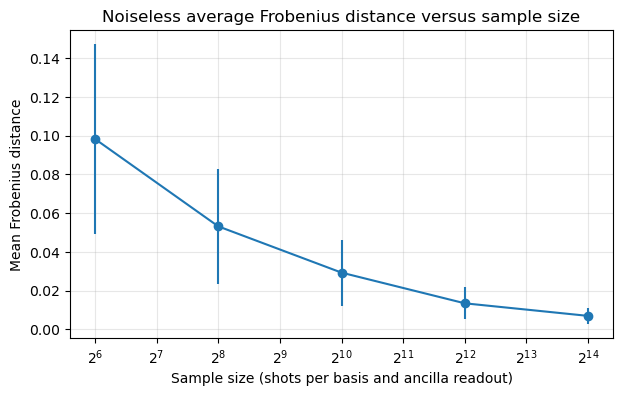

In [8]:
plot_df = summary_df[summary_df['sample_size'] != 'exact'].copy()
plot_df['sample_size'] = plot_df['sample_size'].astype(int)

plt.figure(figsize=(7, 4))
plt.errorbar(
    plot_df['sample_size'],
    plot_df['mean_fidelity'],
    yerr=plot_df['std_fidelity'],
    marker='o',
)
plt.xscale('log', base=2)
plt.xlabel('Sample size (shots per basis and ancilla readout)')
plt.ylabel('Mean fidelity')
plt.title('Noiseless average fidelity versus sample size')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(7, 4))
plt.errorbar(
    plot_df['sample_size'],
    plot_df['mean_frobenius_distance'],
    yerr=plot_df['std_frobenius_distance'],
    marker='o',
)
plt.xscale('log', base=2)
plt.xlabel('Sample size (shots per basis and ancilla readout)')
plt.ylabel('Mean Frobenius distance')
plt.title('Noiseless average Frobenius distance versus sample size')
plt.grid(True, alpha=0.3)
plt.show()


## Optional: save the averaged results to CSV


In [10]:
output_csv = Path.cwd() / 'execution_noiseless_summary_results.csv'
summary_df.to_csv(output_csv, index=False)
